In [226]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/organizations/uciml/autompg-dataset/auto-mpg.csv


In [227]:
# Download latest version
path = kagglehub.dataset_download("uciml/autompg-dataset")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/datasets/organizations/uciml/autompg-dataset


In [228]:
df = pd.read_csv(path+'/auto-mpg.csv')
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino


Attribute Information:

mpg: continuous<br>
cylinders: multi-valued discrete<br>
displacement: continuous<br>
horsepower: continuous<br>
weight: continuous<br>
acceleration: continuous<br>
model year: multi-valued discrete<br>
origin: multi-valued discrete<br>
car name: string (unique for each instance)

In [229]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    398 non-null    object 
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model year    398 non-null    int64  
 7   origin        398 non-null    int64  
 8   car name      398 non-null    object 
dtypes: float64(3), int64(4), object(2)
memory usage: 28.1+ KB


In [230]:
# remove car name column
df = df.iloc[:, :-1]
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin
0,18.0,8,307.0,130,3504,12.0,70,1
1,15.0,8,350.0,165,3693,11.5,70,1
2,18.0,8,318.0,150,3436,11.0,70,1
3,16.0,8,304.0,150,3433,12.0,70,1
4,17.0,8,302.0,140,3449,10.5,70,1


In [231]:
# check for null values
df.isnull().value_counts()

mpg    cylinders  displacement  horsepower  weight  acceleration  model year  origin
False  False      False         False       False   False         False       False     398
Name: count, dtype: int64

### Cylinders is a categorical, but will still work coz its an increasing numeric value from 3 to 8

In [232]:
df['origin'].value_counts()
# 1: USA
# 2: Europe
# 3: Japan

origin
1    249
3     79
2     70
Name: count, dtype: int64

In [233]:
# splitting origin into 3 columns, where each column has 1 0. origin_1 has 1 for all cars with origin as 1, origin_2 has 1 for all origin = 2
# origin_3 is not created because it is understood that if 2 and 3 = 0, then 1 is obviously true(1)
# One-Hot Encoding for 'origin'
df = pd.get_dummies(df, columns=['origin'], drop_first=True, dtype=int)
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin_2,origin_3
0,18.0,8,307.0,130,3504,12.0,70,0,0
1,15.0,8,350.0,165,3693,11.5,70,0,0
2,18.0,8,318.0,150,3436,11.0,70,0,0
3,16.0,8,304.0,150,3433,12.0,70,0,0
4,17.0,8,302.0,140,3449,10.5,70,0,0


In [234]:
df['origin_2'].value_counts(), df['origin_3'].value_counts() 

(origin_2
 0    328
 1     70
 Name: count, dtype: int64,
 origin_3
 0    319
 1     79
 Name: count, dtype: int64)

In [235]:
# convert int64 to float
df['horsepower'] = pd.to_numeric(df['horsepower'], errors='coerce')

In [236]:
# check null
df['horsepower'].isnull().value_counts()

horsepower
False    392
True       6
Name: count, dtype: int64

In [237]:
# fill null values with median
df['horsepower'] = df['horsepower'].fillna(df['horsepower'].median())
df['horsepower'].isnull().value_counts()

horsepower
False    398
Name: count, dtype: int64

In [238]:
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin_2,origin_3
0,18.0,8,307.0,130.0,3504,12.0,70,0,0
1,15.0,8,350.0,165.0,3693,11.5,70,0,0
2,18.0,8,318.0,150.0,3436,11.0,70,0,0
3,16.0,8,304.0,150.0,3433,12.0,70,0,0
4,17.0,8,302.0,140.0,3449,10.5,70,0,0


In [239]:
# check for nulls
for i in range(0, df.shape[1]):
    print(df.iloc[:, i].isnull().value_counts())

mpg
False    398
Name: count, dtype: int64
cylinders
False    398
Name: count, dtype: int64
displacement
False    398
Name: count, dtype: int64
horsepower
False    398
Name: count, dtype: int64
weight
False    398
Name: count, dtype: int64
acceleration
False    398
Name: count, dtype: int64
model year
False    398
Name: count, dtype: int64
origin_2
False    398
Name: count, dtype: int64
origin_3
False    398
Name: count, dtype: int64


In [240]:
# split to Target and features
X = df.iloc[:, 1:]
y = df.iloc[:, 0]
X.head(), y.head()

(   cylinders  displacement  horsepower  weight  acceleration  model year  \
 0          8         307.0       130.0    3504          12.0          70   
 1          8         350.0       165.0    3693          11.5          70   
 2          8         318.0       150.0    3436          11.0          70   
 3          8         304.0       150.0    3433          12.0          70   
 4          8         302.0       140.0    3449          10.5          70   
 
    origin_2  origin_3  
 0         0         0  
 1         0         0  
 2         0         0  
 3         0         0  
 4         0         0  ,
 0    18.0
 1    15.0
 2    18.0
 3    16.0
 4    17.0
 Name: mpg, dtype: float64)

In [241]:
import seaborn as sns
import matplotlib.pyplot as plt

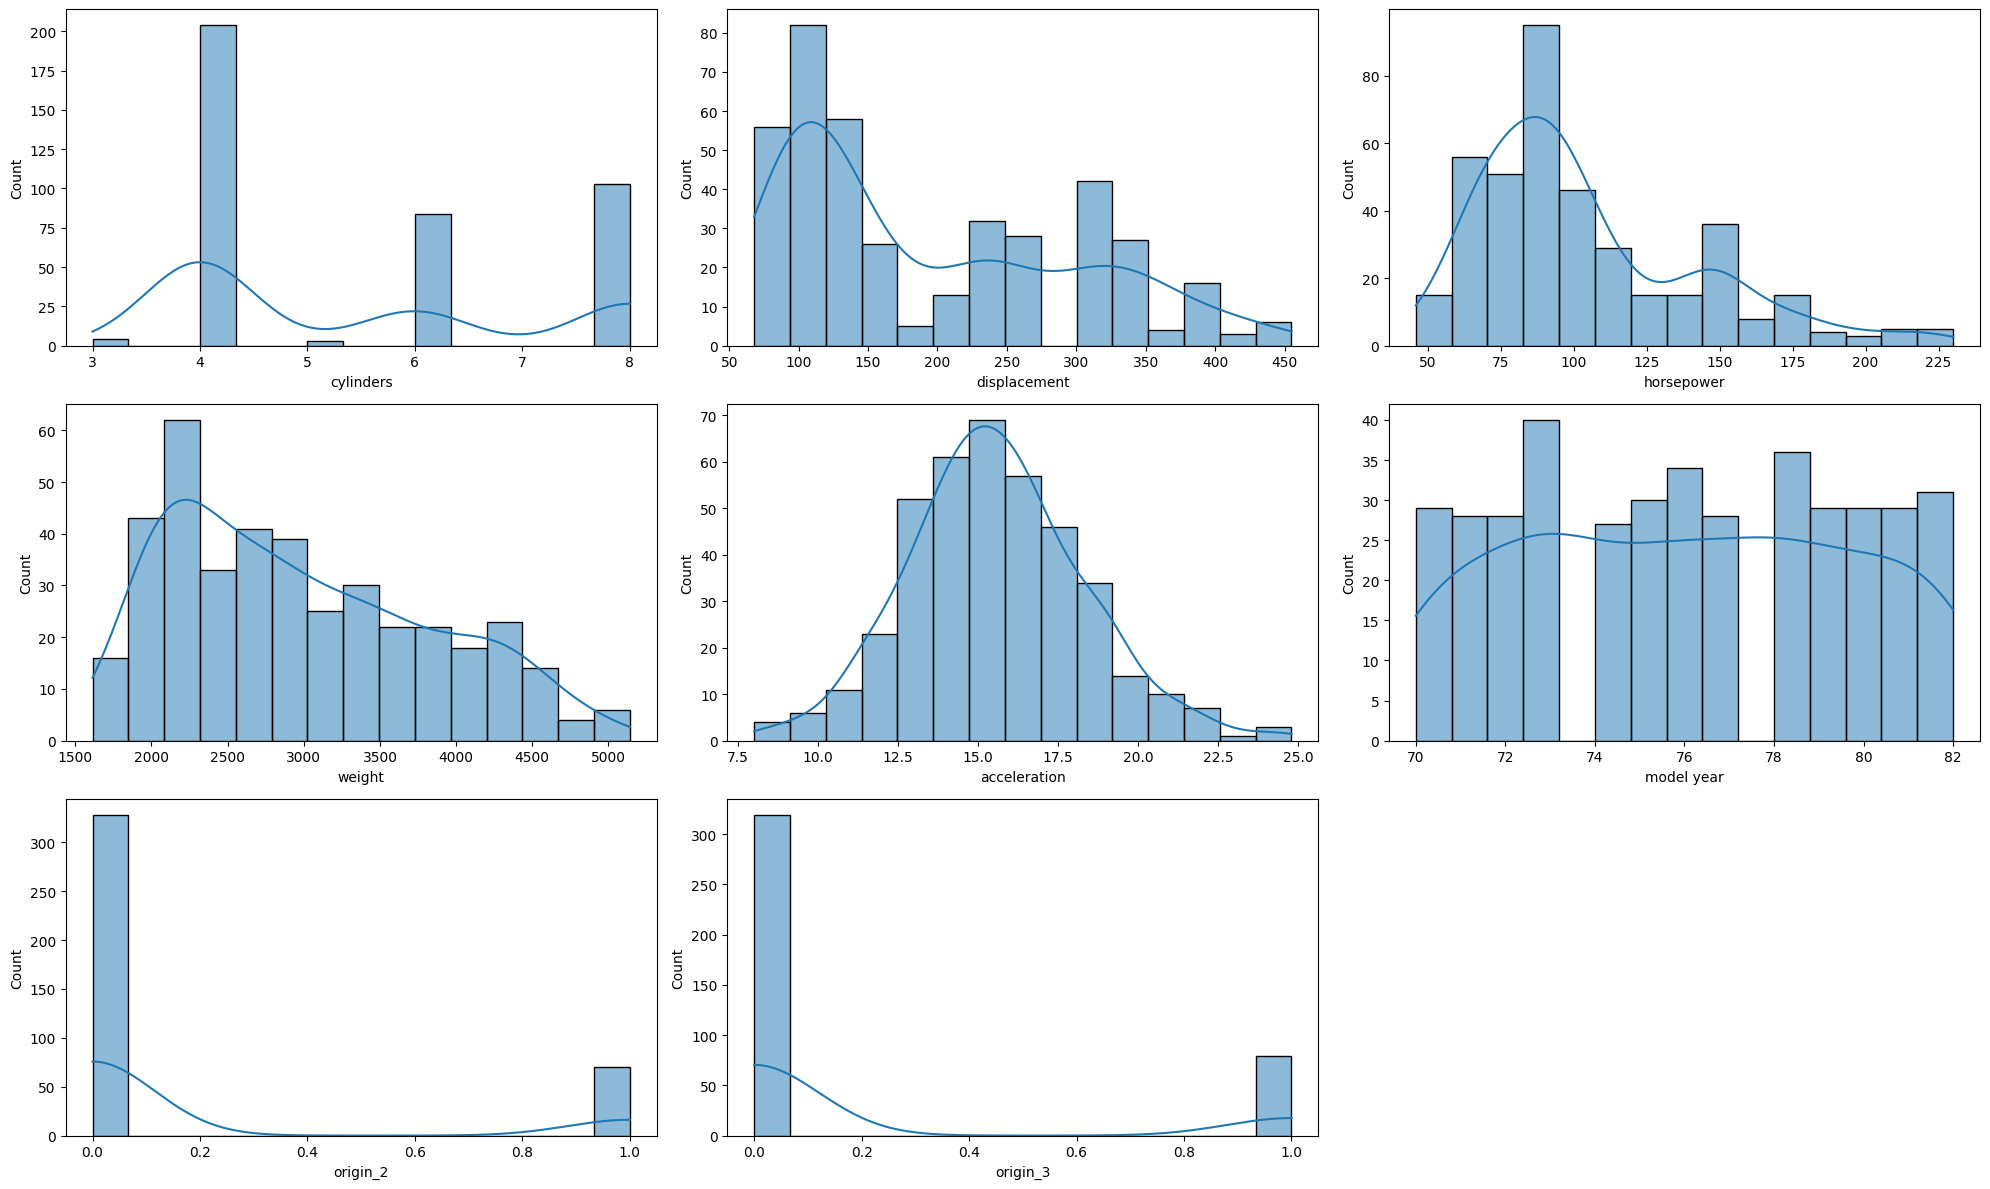

In [242]:
import math
fig = plt.figure(figsize=(20, 12))

cols = 3
rows = math.ceil(len(X.columns) / cols)

for i, column in enumerate(X.columns):
    ax = fig.add_subplot(rows, cols, i + 1)
    sns.histplot(X[column], kde=True, ax=ax, bins = 15)

plt.tight_layout()
plt.show()

In [243]:
# fixing the right skewness in 'displacement', 'horsepower', 'weight'
X[['displacement', 'horsepower', 'weight']] = np.log1p(X[['displacement', 'horsepower', 'weight']])

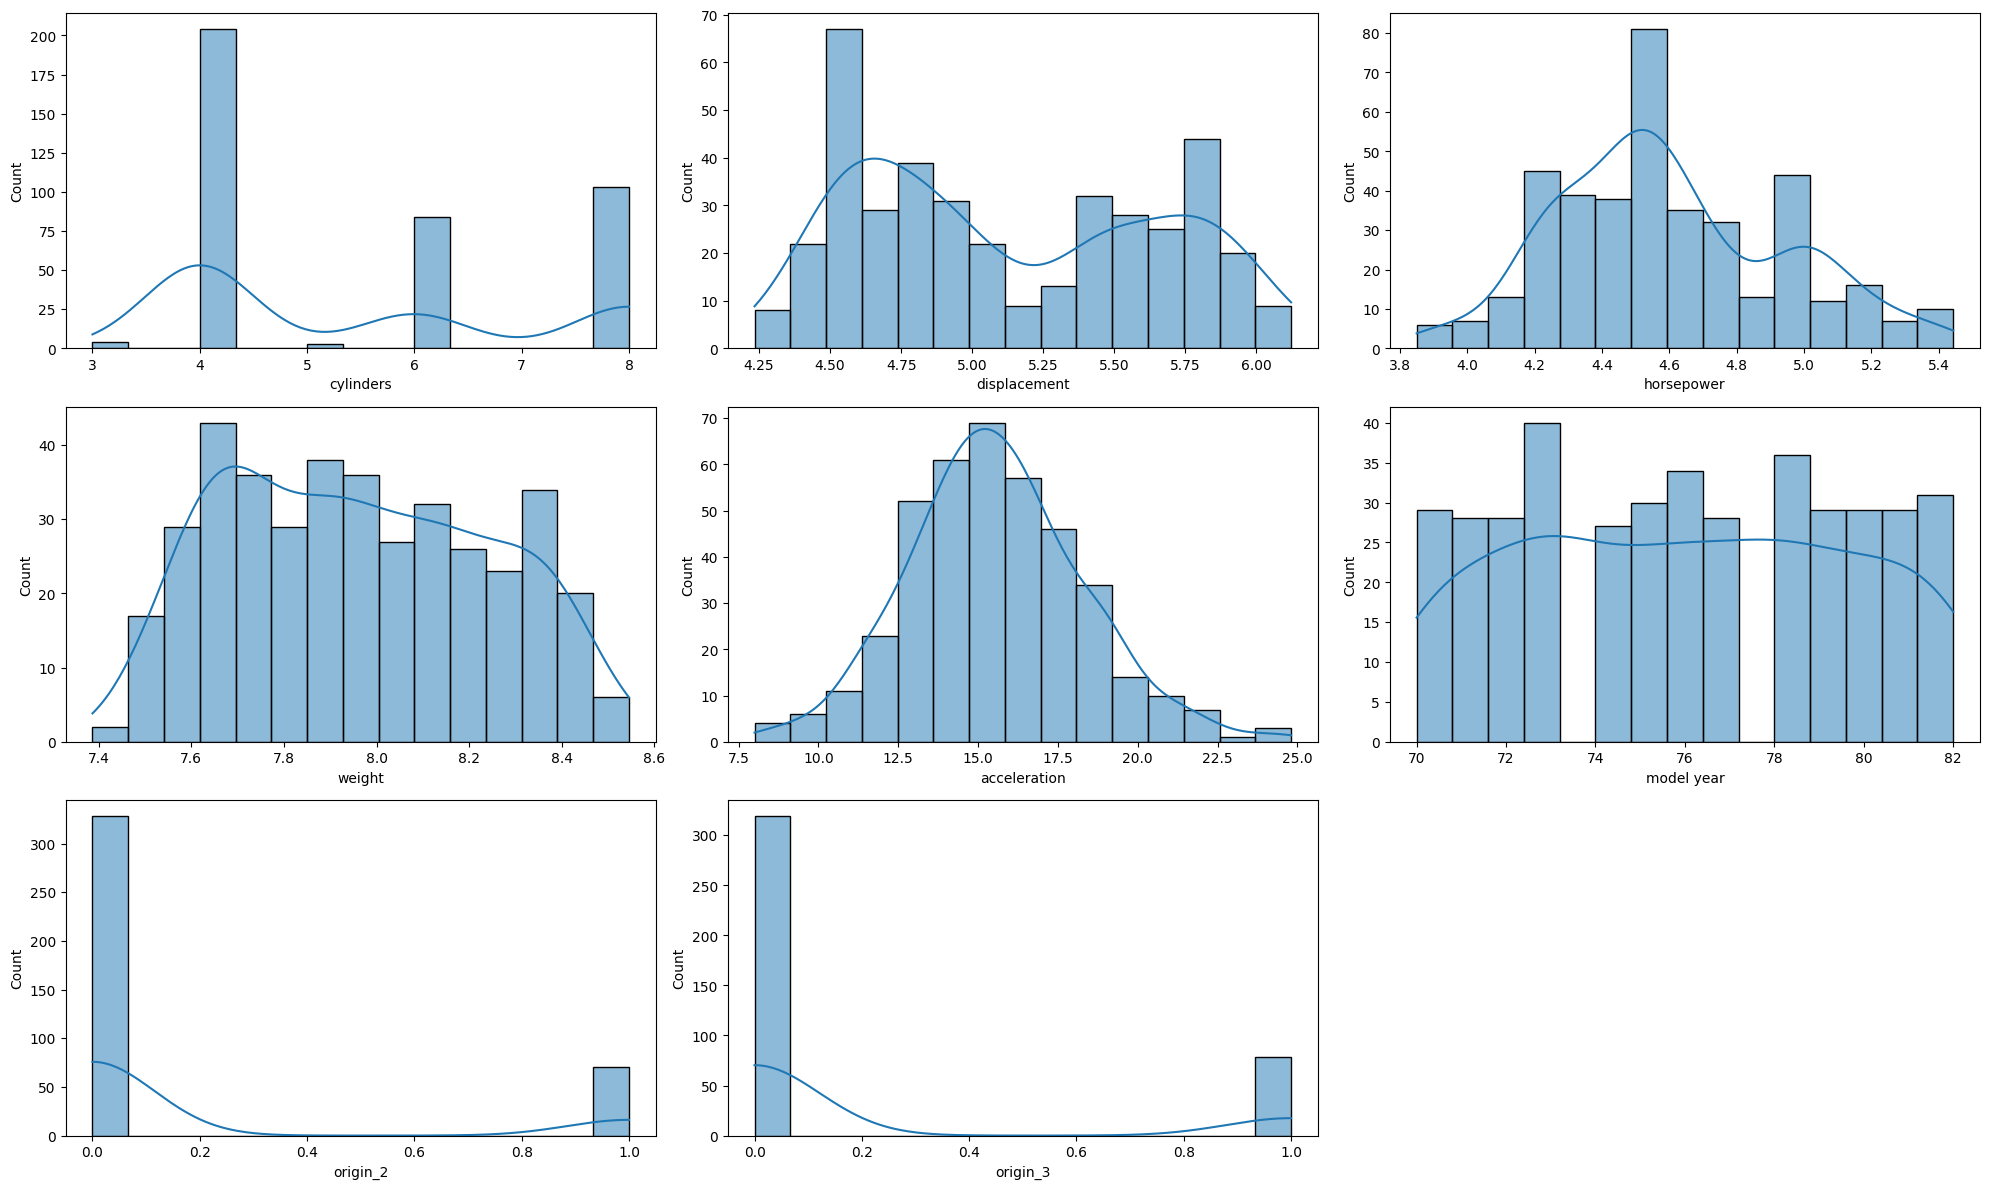

In [244]:
fig = plt.figure(figsize=(20, 12))

cols = 3
rows = math.ceil(len(X.columns) / cols)

for i, column in enumerate(X.columns):
    ax = fig.add_subplot(rows, cols, i + 1)
    sns.histplot(X[column], kde=True, ax=ax, bins = 15)

plt.tight_layout()
plt.show()

In [245]:
from sklearn.model_selection import train_test_split

In [246]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)
X_train

,cylinders,displacement,horsepower,weight,acceleration,model year,origin_2,origin_3
3,8,5.720312,5.017280,8.141481,12.0,70,0,0
18,4,4.584967,4.488636,7.664347,14.5,70,0,1
376,4,4.521789,4.234107,7.613819,18.2,82,0,1
248,4,4.521789,4.110874,7.496097,16.4,78,0,1
177,4,4.753590,4.564348,7.899153,15.0,75,1,0
...,...,...,...,...,...,...,...,...
71,3,4.262680,4.584967,7.754053,13.5,72,0,1
106,8,5.860786,5.198497,8.411833,12.5,73,0,0
270,4,4.905275,4.564348,7.830426,14.8,78,0,1
348,4,4.499810,4.143135,7.626083,17.3,81,0,1


In [247]:
from sklearn.preprocessing import StandardScaler

In [248]:
scaler = StandardScaler()

In [249]:
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [250]:
from sklearn.linear_model import LinearRegression, LogisticRegression

In [251]:
linear_regression_model = LinearRegression()
linear_regression_model.fit(X_train, y_train)

LinearRegression()

In [252]:
y_pred = linear_regression_model.predict(X_test)
comp = pd.DataFrame({'original':y_test, 'predicted': y_pred})
comp.head()

,original,predicted
198,33.0,34.200652
396,28.0,29.095892
33,19.0,20.421281
208,13.0,16.978070
93,14.0,13.187045


In [253]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

In [254]:
r2_linear_reg = r2_score(y_test, y_pred)
mse_linear_reg = mean_squared_error(y_test, y_pred)
rmse_linear_reg = np.sqrt(mse_linear_reg)
mae_linear_reg = mean_absolute_error(y_test, y_pred)
r2_linear_reg, mse_linear_reg, rmse_linear_reg, mae_linear_reg

(0.8618188179657308,
 7.42951075115405,
 np.float64(2.725712888613555),
 2.1044326488766965)

In [255]:
from sklearn.neighbors import KNeighborsRegressor

In [256]:
error_rate = []

for i in range(1, 11):
    KNN_Regressor = KNeighborsRegressor(n_neighbors = i)
    KNN_Regressor.fit(X_train, y_train)
    pred_i = KNN_Regressor.predict(X_test)
    # error_rate.append(np.mean(pred_i != y_test)) # mean of values which are not the same as the expected value
    error = mean_absolute_error(y_test, pred_i)
    error_rate.append(error)
error_rate.index(min(error_rate)) + 1

7

[]

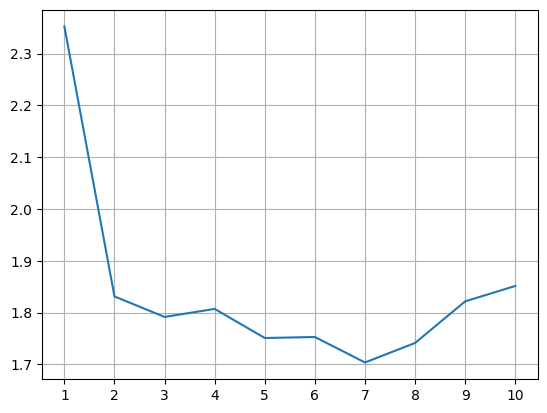

In [257]:
plt.plot(range(1, 11), error_rate)
plt.xticks(range(1, 11))
plt.grid()
plt.plot()

In [258]:
KNN_Regressor_5 = KNeighborsRegressor(n_neighbors = 5)
KNN_Regressor_5.fit(X_train, y_train)
y_pred = KNN_Regressor_5.predict(X_test)
comp = pd.DataFrame({'original':y_test, 'predicted':y_pred})
comp.head()

,original,predicted
198,33.0,32.52
396,28.0,29.08
33,19.0,18.80
208,13.0,15.30
93,14.0,14.60


In [259]:
r2_knn_5 = r2_score(y_test, y_pred)
mse_knn_5 = mean_squared_error(y_test, y_pred)
rmse_knn_5 = np.sqrt(mse_knn_5)
mae_knn_5 = mean_absolute_error(y_test, y_pred)
r2_knn_5, mse_knn_5, rmse_knn_5, mae_knn_5

(0.9077387371375106,
 4.960560000000001,
 np.float64(2.2272314652949747),
 1.7510000000000001)

In [260]:
# with k = 7
KNN_Regressor_7 = KNeighborsRegressor(n_neighbors = 7)
KNN_Regressor_7.fit(X_train, y_train)
y_pred = KNN_Regressor_7.predict(X_test)
comp = pd.DataFrame({'original':y_test, 'predicted':y_pred})
comp.head()

,original,predicted
198,33.0,32.300000
396,28.0,28.428571
33,19.0,18.428571
208,13.0,15.285714
93,14.0,14.142857


In [261]:
r2_knn_7 = r2_score(y_test, y_pred)
mse_knn_7 = mean_squared_error(y_test, y_pred)
rmse_knn_7 = np.sqrt(mse_knn_7)
mae_knn_7 = mean_absolute_error(y_test, y_pred)
r2_knn_7, mse_knn_7, rmse_knn_7, mae_knn_7

(0.9050025319852373,
 5.107676020408164,
 np.float64(2.2600168186117915),
 1.70375)

# best algo as of now: KNN with k = 5 gets an r2 score of 0.90773

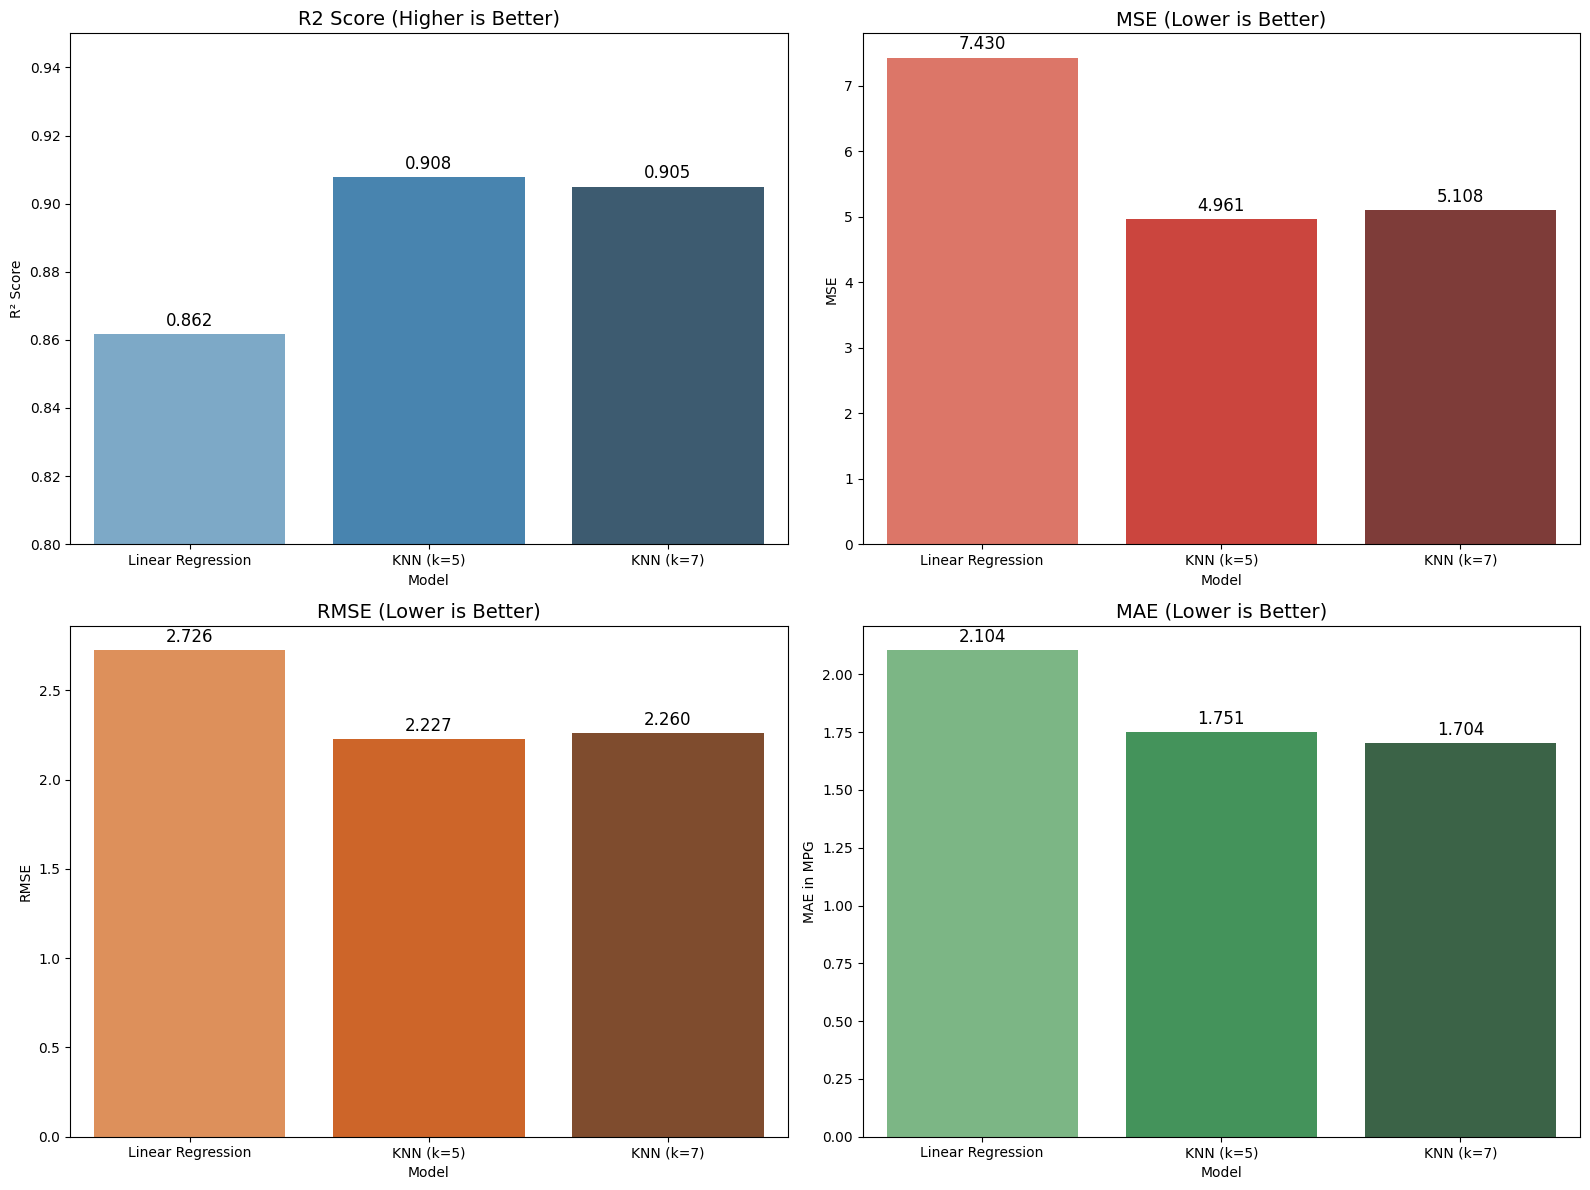

In [273]:
results_df = pd.DataFrame({
    'Model': ['Linear Regression', 'KNN (k=5)', 'KNN (k=7)'],
    'R2 Score': [r2_linear_reg, r2_knn_5, r2_knn_7], 
    'MSE': [mse_linear_reg, mse_knn_5, mse_knn_7],
    'RMSE': [rmse_linear_reg, rmse_knn_5, rmse_knn_7],
    'MAE(MPG)': [mae_linear_reg, mae_knn_5, mae_knn_7],
})

# 2x2 grid canvas
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Flatten the 2x2 grid into a 1D list of 4 boxes
axes = axes.flatten() 

sns.barplot(data=results_df, x='Model', y='R2 Score', ax=axes[0], hue='Model', palette='Blues_d')
axes[0].set_title('R2 Score (Higher is Better)', fontsize=14)
axes[0].set_ylim(0.80, 0.95) 
axes[0].set_ylabel('R² Score')

# 4. Plot MSE 
sns.barplot(data=results_df, x='Model', y='MSE', ax=axes[1], hue='Model', palette='Reds_d')
axes[1].set_title('MSE (Lower is Better)', fontsize=14)
axes[1].set_ylabel('MSE')

# 5. Plot RMSE 
sns.barplot(data=results_df, x='Model', y='RMSE', ax=axes[2], hue='Model', palette='Oranges_d')
axes[2].set_title('RMSE (Lower is Better)', fontsize=14)
axes[2].set_ylabel('RMSE')

# 6. Plot MAE 
sns.barplot(data=results_df, x='Model', y='MAE(MPG)', ax=axes[3], hue='Model', palette='Greens_d')
axes[3].set_title('MAE (Lower is Better)', fontsize=14)
axes[3].set_ylabel('MAE in MPG')

# 7. Add the exact numbers on top of the bars
for ax in axes:
    for container in ax.containers:
        ax.bar_label(container, fmt='%.3f', padding=3, fontsize=12)

# Clean up the spacing and display the plot
plt.tight_layout()
plt.show()

In [268]:
custom_car = pd.DataFrame({
    'cylinders': [4],
    'displacement': [110],  
    'horsepower': [85],
    'weight': [2100],
    'acceleration': [16.0],
    'model year': [80],
    'origin_2': [0], # 0 = Not Europe
    'origin_3': [1]  # 1 = Japan (Since both are 0 for USA)
})

custom_car[['weight', 'horsepower', 'displacement']] = np.log1p(custom_car[['weight', 'horsepower', 'displacement']])


custom_car_scaled = scaler.transform(custom_car)

# 4. Make the prediction
predicted_mpg_knn_5 = KNN_Regressor.predict(custom_car_scaled)
predicted_mpg_linear = linear_regression_model.predict(custom_car_scaled)

print(f"Custom Car Predicted MPG for knn(5): {predicted_mpg_knn_5[0]:.2f}\nCustom Car Predicted MPG for LinReg: {predicted_mpg_linear[0]:.2f}")

Custom Car Predicted MPG for knn(5): 32.00
Custom Car Predicted MPG for LinReg: 32.70
